## 黒潮東側付近におけるカルマンフィルタ


In [1]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
import tqdm

## パラメータの設定

In [2]:
deg_per_mesh = 1/36
ais_lat_max = 1800
ais_lat_min = 750
ais_lon_max = 5401
ais_lon_min = 4211
lat_range = [20-1/36, 50+1/36]
lon_range = [117-1/36, 150+1/36]
map_size_ais = [1050, 1191]
map_size_jcope = [1082, 1191]

### 論文を参考に黒潮付近を設定
黒潮付近<br>
(32, 130), (30, 130), (34, 142), (36,　142)<br>
データ数削減のため，データ範囲をいかに変更<br>
(32, 136), (30, 136), (34, 142), (36,　142)<br>

In [3]:
kurosio_lat_range1 = [30, 32]
kurosio_lat_range2 = [34, 36]
kurosio_lon_range = [136, 142]
line1 = [[kurosio_lat_range1[0], kurosio_lon_range[0]], [kurosio_lat_range2[0], kurosio_lon_range[1]]]
line2 = [[kurosio_lat_range2[0], kurosio_lon_range[1]], [kurosio_lat_range2[1], kurosio_lon_range[1]]]
line3 = [[kurosio_lat_range2[1], kurosio_lon_range[1]], [kurosio_lat_range1[1], kurosio_lon_range[0]]]
line3 = [[kurosio_lat_range1[1], kurosio_lon_range[0]], [kurosio_lat_range1[0], kurosio_lon_range[0]]]

kurosio_row_range1 = [int((kurosio_lat_range1[0]-lat_range[0])/deg_per_mesh), int((kurosio_lat_range1[1]-lat_range[0])/deg_per_mesh)]
kurosio_row_range2 = [int((kurosio_lat_range2[0]-lat_range[0])/deg_per_mesh), int((kurosio_lat_range2[1]-lat_range[0])/deg_per_mesh)]
kurosio_col_range = [int((kurosio_lon_range[0]-lon_range[0])/deg_per_mesh), int((kurosio_lon_range[1]-lon_range[0])/deg_per_mesh)]

## 関数の定義

In [4]:
# data: 1*(n+m)
def dummy_jcope_data(x0, dx, count, noise_factor, size=[10, 10]):
    data = []
    for i in range(count):
        data.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        data[i].append(0)
    return data

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data(x0, dx, omega, count, noise_factor, size=[10, 10]):
    xy = []
    sum_w = []
    for i in range(count):
        xy.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        xy[i].append(1)
        sum_w[i].append(0.00001)
    return xy, sum_w

# dummpy ais data
# data: 1*(n+m)
def dummy_ais_data2(x0, dx, omega, count, noise_factor, size=[10, 10]):
    v = []
    theta = []
    sum_w = []
    for i in range(count):
        v.append([x0+ dx*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        theta.append([x0+ omega*i + randn()*noise_factor for nm in range(size[0]+size[1])])
        sum_w.append([1/(2*noise_factor)  for nm in range(size[0]+size[1])])
        v[i].append(1)
        theta[i].append(0)
        sum_w[i].append(0)
    return v, theta, sum_w

# lat lon -> mesh 
def latlon_to_mesh(lat, lon, size=[865, 831]):
    lat_range = lat_range
    lon_range = lon_range
    # lat, lon -> [lon, lat]
    grid0 = int((lon-lon_range[1])/deg_per_mesh)
    grid1 = int((lat-lat_range[0])/deg_per_mesh)
    if grid0<0 or grid0>size[0]: return [-1, -1]
    if grid1<0 or grid1>size[1]: return [-1, -1]
    return [grid0, grid1]

def aisIdx_to_rallon(lat_idx, lon_idx):
    return [lat_idx, lon_idx]*deg_per_mesh

def kurosio(row, col):
    dx = kurosio_col_range[1]-kurosio_col_range[0]
    dy1 = kurosio_row_range2[0] - kurosio_row_range1[0]
    a1 = dy1/dx
    b1 = kurosio_row_range1[0] - a1*kurosio_col_range[0]
    dy2 = kurosio_row_range2[1] - kurosio_row_range1[1]
    a2 = dy2/dx
    b2 = kurosio_row_range1[1] - a1*kurosio_col_range[0]
    
    if(col<kurosio_col_range[0] or col>kurosio_col_range[1]):
        return False
    if(a1*col+b1 > row or a2*col+b2 < row):
        return False
    return True

def kurosio_filter(data, marine_map):
    res = []
    for i in range(map_size_ais[0]):
        for j in range(map_size_ais[1]):
            if kurosio(i, j) and marine_map[i][j]==marine_map[i][j]:
                res.append(data[i][j])
    return np.array(res)

# JCOPE
jcope_data = dummy_jcope_data(0, 0.1, 100, 0.01)

# AIS(観測値) 
ais_data = dummy_ais_data(0, 0.1, 1, 100, 0.001)

# 黒潮マップ
kurosio_map = np.zeros((map_size_ais)) * np.nan
for i in range(map_size_ais[0]):
    for j in range(map_size_ais[1]):
        if kurosio(i, j):
            kurosio_map[map_size_ais[0]-i][j] = 1

kurosio_map_tf = np.zeros((map_size_ais)) == 1 
for i in range(map_size_ais[0]):
    for j in range(map_size_ais[1]):
        if kurosio(i, j):
            kurosio_map_tf[map_size_ais[0]-i][j] = True

## データの読み込み

In [5]:
# pathの設定
path_ais = [ fr'./data/ais/20150919\150919-{i}log\log' for i in range(5, 13)] # 0-14時
path_jcope = [fr'./data/eas\2015091900{i}' for i in range(24)] # 0-23時

# AIS (MAP curN, curE)
date = [i for i in range(1817, 1824, 2)] + [i for i in range(1900, 1916, 2)]
ais_n_mapped = []
for i, p in enumerate(path_ais):
    ais_n_mapped.append(pd.read_csv(p+f"/AisCurr20150919{i*2:02}N.csv", encoding="cp932",))
    ais_n_mapped.append(pd.read_csv(p+f"/AisCurr20150919{i*2+1:02}N.csv", encoding="cp932",))
ais_e_mapped = []
for i, p in enumerate(path_ais):
    ais_e_mapped.append(pd.read_csv(p+f"/AisCurr20150919{i*2:02}E.csv", encoding="cp932",))
    ais_e_mapped.append(pd.read_csv(p+f"/AisCurr20150919{i*2+1:02}E.csv", encoding="cp932",))
    
# JCOPE (MAP curN, curE)
jcope_n = []
for p in path_jcope:
    jcope_n.append(pd.read_csv(p+"/N.csv", encoding="cp932",))
jcope_e = []
for p in path_jcope:
    jcope_e.append(pd.read_csv(p+"/E.csv", encoding="cp932",))


In [6]:
for i in range(len(jcope_n)):
    jcope_n[i] = jcope_n[i][0:1050]

for i in range(len(jcope_e)):
    jcope_e[i] = jcope_e[i][0:1050]

nan_map = np.array(jcope_n[0])*0+1

## 黒潮領域の確認

Kurosio:(1050, 1191)


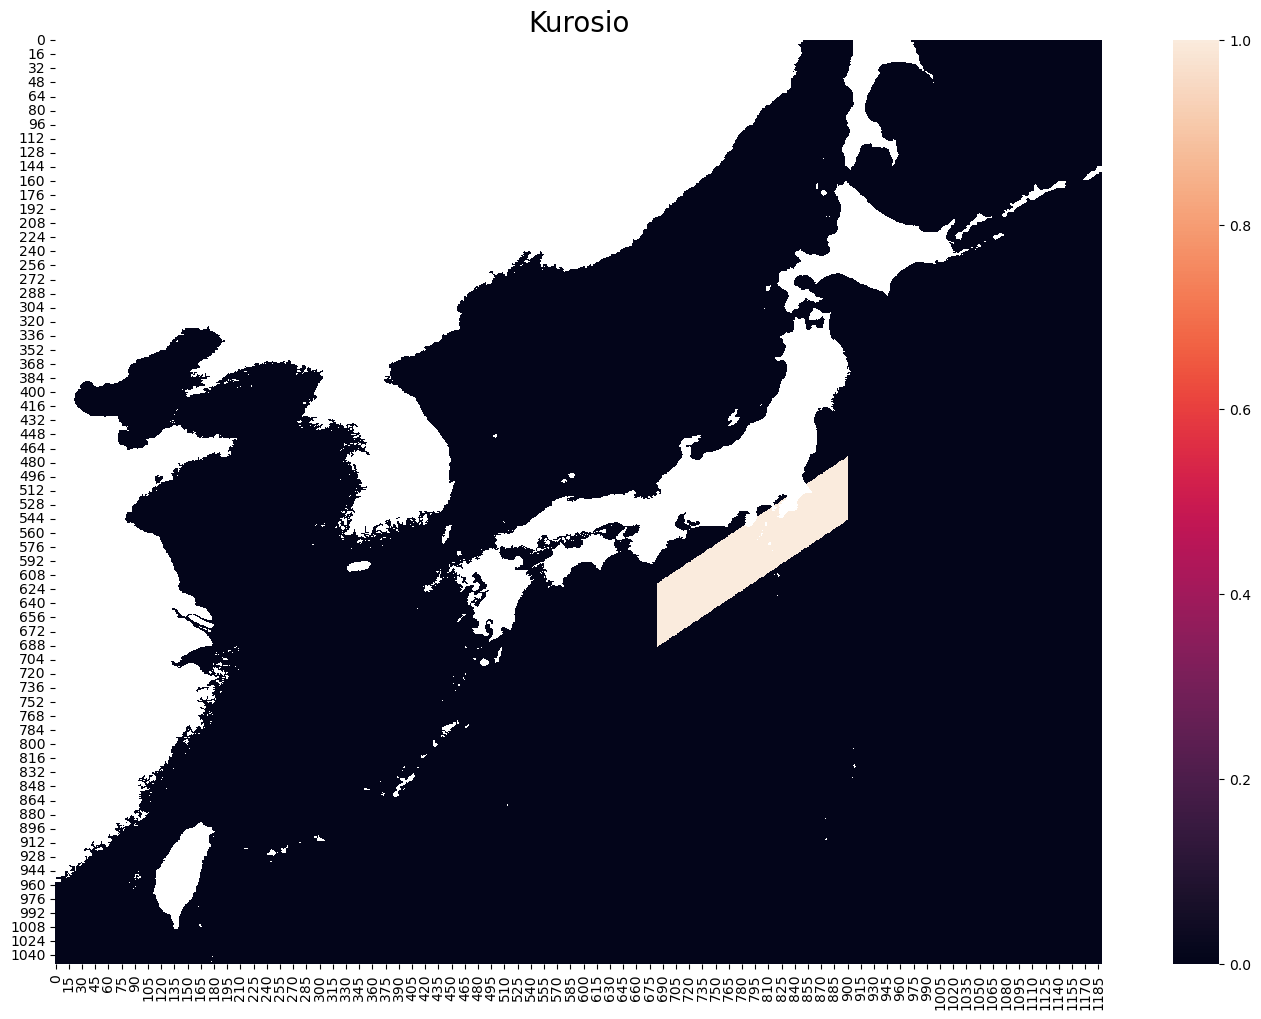

In [7]:
datas = [kurosio_map_tf*nan_map]
data_names = ['Kurosio']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    axes.set_aspect('equal', adjustable='box')
    axes.set_title(data_names[i], fontsize=20)
    axes.set_xlim(0, 1050)
    axes.set_ylim(0, 1090)
    sns.heatmap(data, ax=axes)
plt.show()

全データの可視化

AIS N:(1050, 1191)
AIS E:(1050, 1191)
JCOPE N:(1050, 1191)
JCOPE E:(1050, 1191)


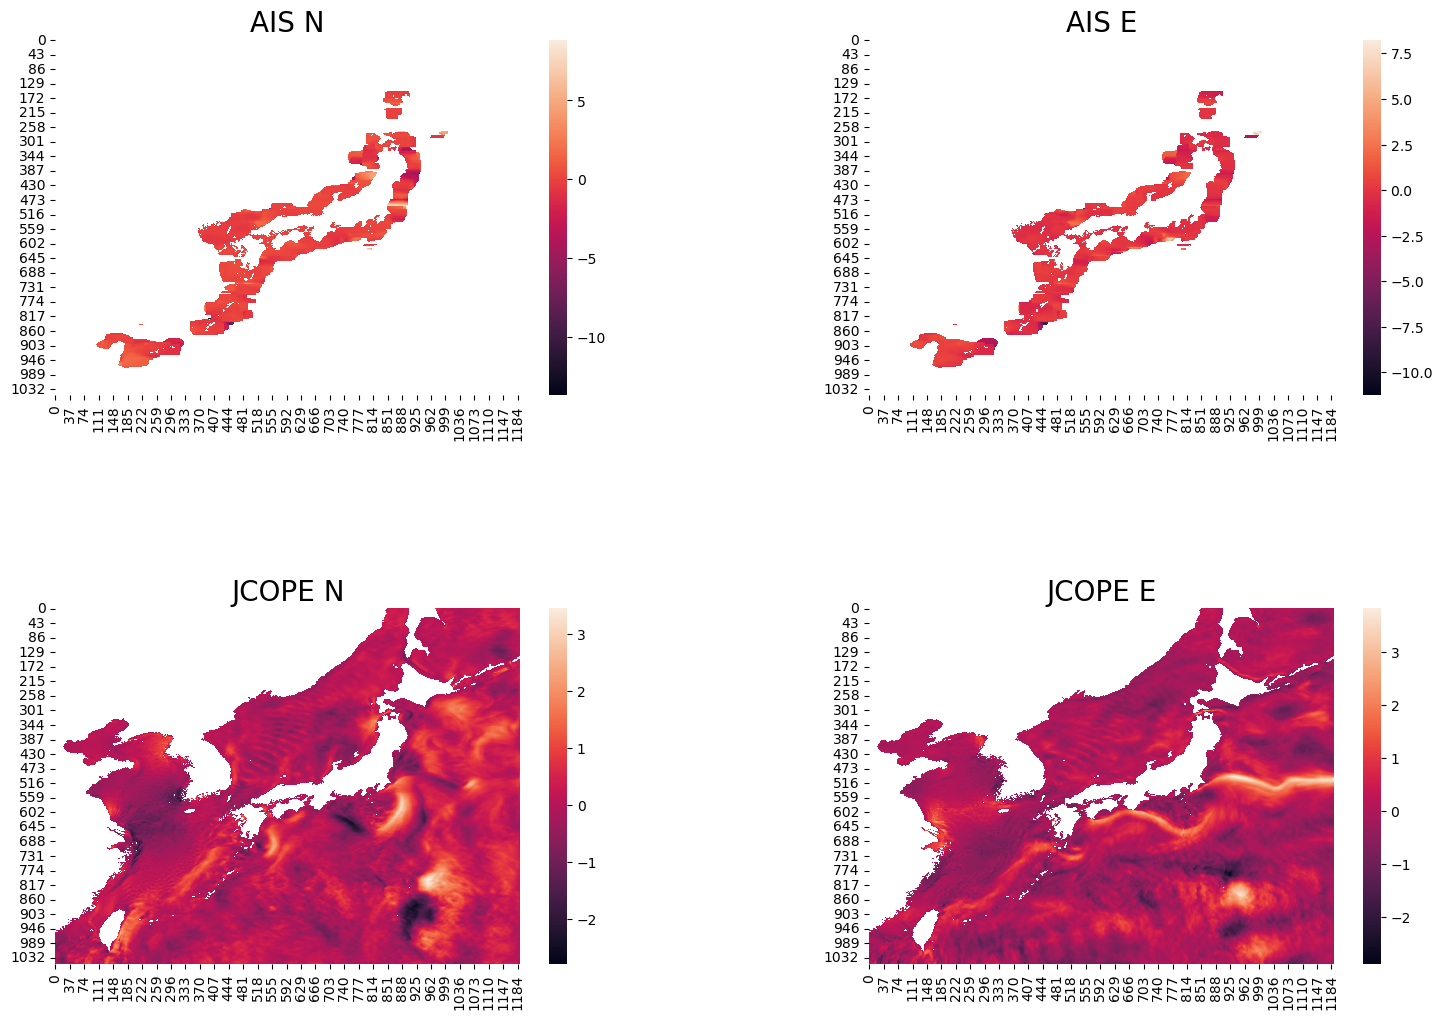

In [8]:
datas = [ais_n_mapped[0], ais_e_mapped[0], jcope_n[0], jcope_e[0]]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

黒潮のみ可視化

AIS N:(1050, 1191)
AIS E:(1050, 1191)
JCOPE N:(1050, 1191)
JCOPE E:(1050, 1191)


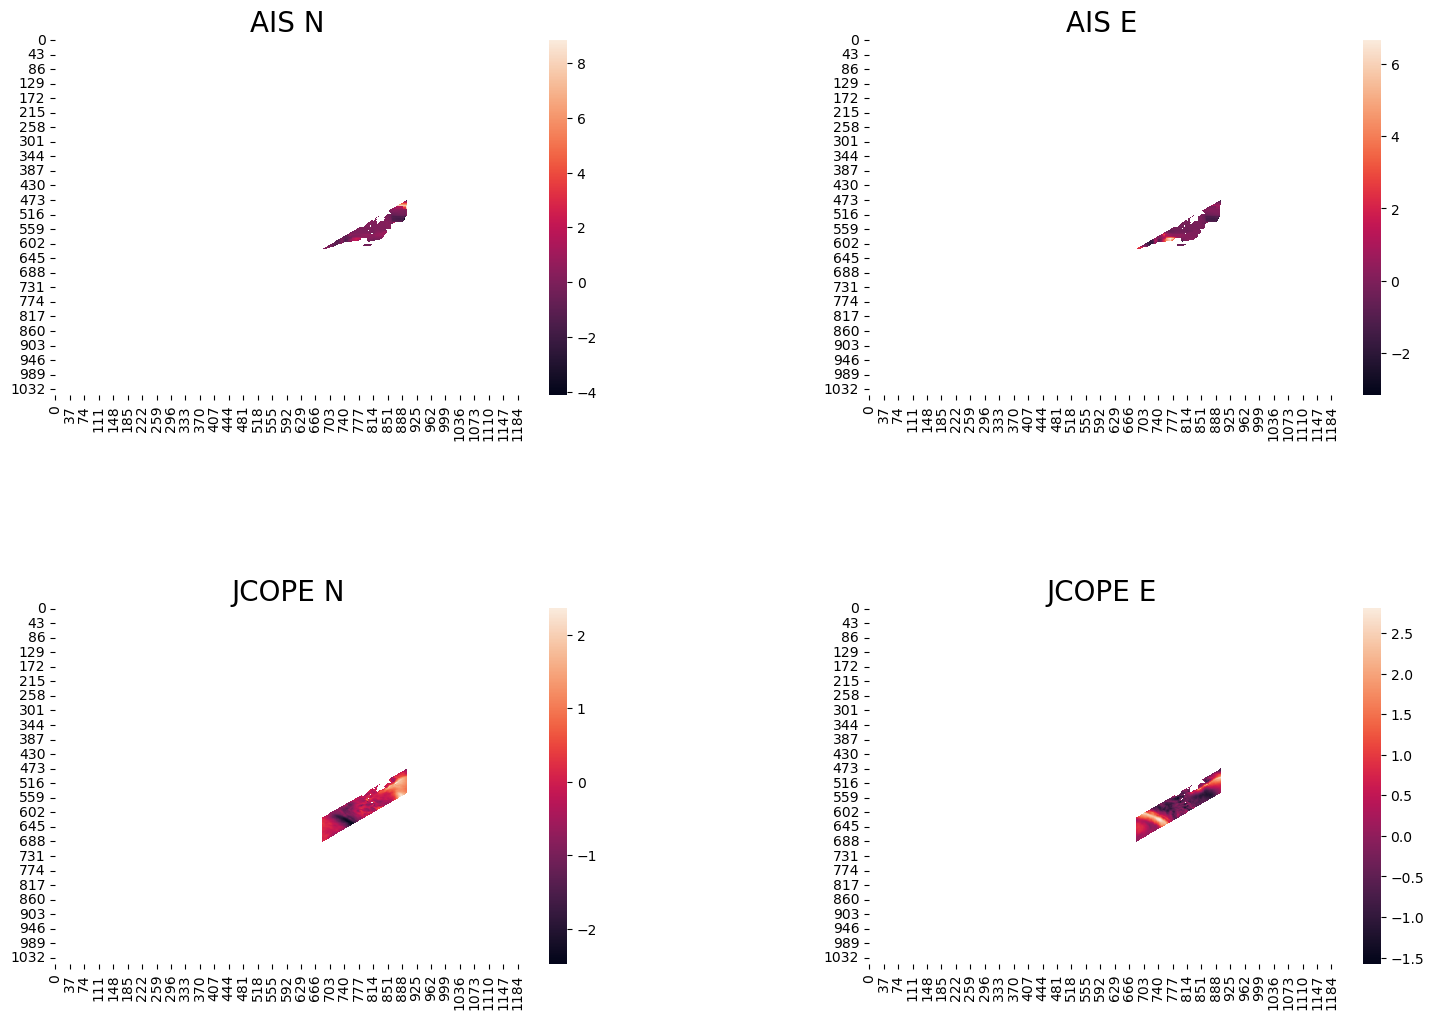

In [9]:
datas = [ais_n_mapped[0]*kurosio_map, 
         ais_e_mapped[0]*kurosio_map, 
         jcope_n[0]*kurosio_map, 
         jcope_e[0]*kurosio_map]
data_names = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plot_place = [[0, 0], [0, 1], [1, 0], [1, 1]] # plot する場所
for i, data in enumerate(datas):
    print(f"{data_names[i]}:{data.shape}")
    a, b = plot_place[i]
    axes[a, b].set_title(data_names[i], fontsize=20)
    axes[a, b].set_xlim(0, 1082)
    axes[a, b].set_ylim(0, 1090)
    sns.heatmap(data.values, ax=axes[a, b])
plt.show()

黒潮領域東側のデータ数(陸地を除く)は9808<br>
存在しないデータが半数以上あるので，もっと計算量を小さくはできる<br>
ちなみに，陸地込みの黒潮全域は31321<br>

In [10]:
# 黒潮領域のデータ数の確認
datas = [kurosio_filter(ais_n_mapped[0].values, nan_map), 
         kurosio_filter(ais_e_mapped[0].values, nan_map), 
         kurosio_filter(jcope_n[0].values, nan_map),
         kurosio_filter(jcope_e[0].values, nan_map)]
data_name = ['AIS N', 'AIS E', 'JCOPE N', 'JCOPE E']
for i, d in enumerate(datas):
    print(f"データ名: {data_name[i]}, データ数:{len(d)}, 存在しないデータ数: {np.sum(d!=d)}")

データ名: AIS N, データ数:9808, 存在しないデータ数: 4267
データ名: AIS E, データ数:9808, 存在しないデータ数: 4267
データ名: JCOPE N, データ数:9808, 存在しないデータ数: 0
データ名: JCOPE E, データ数:9808, 存在しないデータ数: 0


## カルマンフィルタの設計
### 状態空間モデル
$\hat{x(t)}^{-} = A\hat{x}(t-1)$<br>
$\hat{x(t)}^{-} = J(K) + a(\hat{x}(t-1)-J(k-1))$<br>
$J(k) = \left[ x(0, 0), x(0, 1), \cdots, x(lon-1, lat-1), \cdots, y(0, 0), y(0, 1), \cdots, y(lon-1, lat-1), 1 \right]$<br>
$
A = 
\begin{pmatrix}
   a & 0 & \cdots & 0 & (J(k)-aJ(k-1))(0, 0) \\
   0 & a & \cdots & 0 & (J(k)-aJ(k-1))(0, 1) \\
   \vdots & \cdots &　 &　 & \vdots  \\
   0 & \cdots & 0 & a & (J(k)-aJ(k-1))(lon-1, lat-1)\\
   0 & \cdots & 0 & 1 & 1
\end{pmatrix}
$
<br>
### 観測値
$y(t) = C\hat{x}(t)$<br>
$y(t) = \left[ x(0, 0), x(0, 1), \cdots, x(lon-1, lat-1), \cdots, y(0, 0), y(0, 1), \cdots, y(lon-1, lat-1), 1 \right]$<br>
$
C = 
\begin{pmatrix}
   1 & 0 & \cdots & 0 & 0 \\
   0 & 1 & \cdots & 0 & 0 \\
   \vdots & \cdots &　 &　 & \vdots  \\
   0 & \cdots & 0 & 1 & 0\\
\end{pmatrix}
$

## 黒潮領域のカルマンフィルター
aisの信頼度のデータを計算するの忘れたので，とりあえず誤差の値は0.01にする

In [11]:
import pickle
from filterpy.common import Saver
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

data = kurosio_filter(ais_n_mapped[0].values, nan_map)
n = len(data)
m = 1

def F_element(i, j, k, data):
    a = 0.5
    if i==j:
        return a
    elif i==n+m:
        jcope0 = data[k-1]
        jcope1 = data[k]
        residual = jcope1[i] - jcope0[i]
        return residual
    else:
        return 0

# TODO
def H_element(i, j):
    if i==j:
        return 1
    else:
        return 0
    
def R_mat(sigma):
    R = np.zeros((n*m+1, n*m+1))
    for i in range(len(sigma)):
        R[i][i] = sigma[i]
    return R


kf = KalmanFilter(dim_x=n*m+1, dim_z=n*m+1)
ais_n0 = kurosio_filter(ais_n_mapped[0].values, nan_map) # 時刻0のais data
ais_n0 = np.concatenate([ais_n0, [1]])
ais_n0 = ais_n0.reshape(len(ais_n0), 1)
ais_n0[ais_n0!=ais_n0] = 0

jcope_n0 = kurosio_filter(jcope_n[0].values, nan_map) # 時刻0のjcope data
jcope_n0 = np.concatenate([jcope_n0, [1]])
jcope_n0 = jcope_n0.reshape(len(jcope_n0), 1)
jcope_n0[jcope_n0!=jcope_n0] = 0

# F関数, H関数
kf.F = np.array([[F_element(i, j, 1, jcope_n0)  for i in range(n*m+1)] for j in range(n*m+1)])
kf.H = np.array([[H_element(i, j)  for i in range(n*m+1)] for j in range(n*m+1)])


# 分散共分散行列
kf.Q = np.eye(n*m+1)*0.001 # システム誤差(ais)
#kf.R = R_mat(ais_sigmas2[0]) # 観測誤差(jcope)
kf.R = np.eye(n*m+1)*0.001

kf.x = jcope_n0 # 初期位置
kf.P = np.eye(n*m+1) # 初期事後誤差共分散行列
s = Saver(kf) # save用

# 10時刻分（13時刻でメモリエラー出るので）
for t in tqdm.tqdm(range(1,10)):
    # 予測ステップ
    kf.predict()
    
    # フィルタリングステップ
    # kf.R = R_mat(ais_sigmas2[t])
    kf.R = np.eye(n*m+1)*0.001
    y = kurosio_filter(ais_n_mapped[t].values, nan_map)
    y = np.concatenate([y, [1]])
    y = y.reshape(len(y), 1)
    y[y!=y] = 0
    # nanの処理と誤差の最大化
    kf.update(y)
    
    """
    target = 88
    if y[target]!=0.0:
        print(f"t:{t}")
        print(f"R:{kf.R[target][target]}")
        print(f"x:{kf.x[target]}")
        print(f"y:{y[target]}") 
    """
    
    s.save()  # 現在状態を記録する
    
    with open(f'data/saverX{t}', 'wb') as f:
        pickle.dump(s.x, f)
    with open(f'data/saverZ{t}', 'wb') as f:
        pickle.dump(s.z, f)
        
    # 関数の更新
    x = kurosio_filter(jcope_n[t].values, nan_map)
    x = np.concatenate([x, [1]])
    x = x.reshape(len(x), 1)
    x[x!=x] = 0
    kf.F = np.array([[F_element(i, j, t, x)  for i in range(n*m+1)] for j in range(n*m+1)])
    kf.H = np.array([[H_element(i, j)  for i in range(n*m+1)] for j in range(n*m+1)])
    
#s.to_array()
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
i = 4
j = 8
plt.title("Filtered by kalman filter")
plt.xlabel("Time")
plt.ylabel(f"({i}, {j}) value")
plt.plot(np.arange(len(np.array(s.x)[:, i])), np.array(s.x)[:, i], label='res')
plt.scatter(np.arange(len(np.array(s.x)[:, i])), np.array(s.z)[:, i], label='obs', c='r')
plt.legend()
plt.show()
np.sum(np.array(s.x) == np.array(s.x))

100%|███████████████████████████████████████████████████████████████████████████████████| 9/9 [28:02<00:00, 186.97s/it]


ValueError: could not convert M into np.array

先頭の2,000くらいのデータは無い<br>

9809


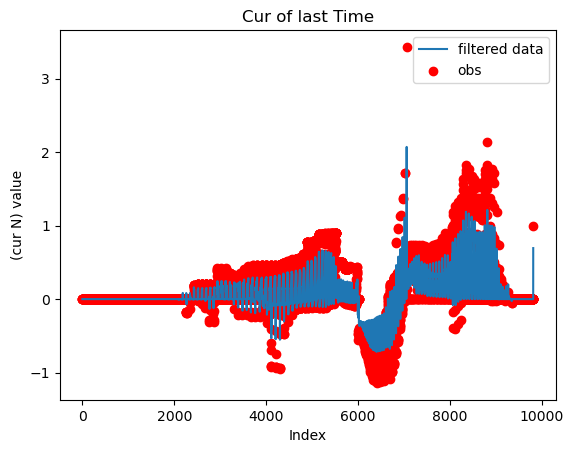

88281

In [29]:
print(len(s.x[0]))
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
plt.title("Cur of last Time")
plt.xlabel("Index")
plt.ylabel(f"(cur N) value")
plt.plot(np.arange(len(np.array(s.x)[-1])), np.array(s.x)[-1], label=f'filtered data')
plt.scatter(np.arange(len(np.array(s.x)[-1])), np.array(s.z)[-1], label=f'obs', c='r')
plt.legend()
plt.show()
np.sum(np.array(s.x) == np.array(s.x))

inexが8,000の場所のフィルター過程を見てみる<br>
大体aisとjcopeの値を終えていてよさそう

9809


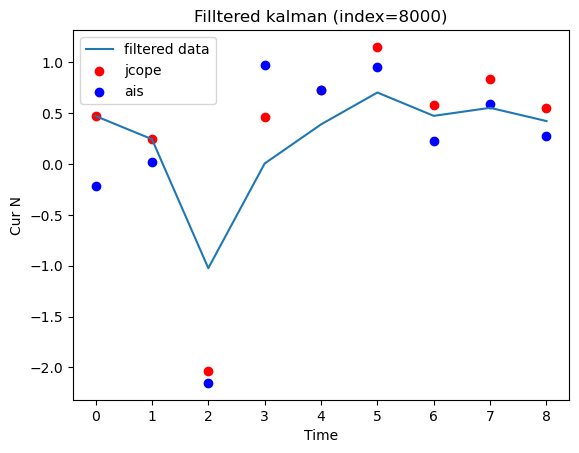

88281

In [49]:
print(len(s.x[0]))
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
i = 8000
dataX = np.array(s.x).T
dataX = dataX[0][i]
dataZ = np.array(s.z).T
dataZ = dataZ[0][i]
dataY = np.array(s.y).T
dataY = dataY[0][i]

plt.title(f"Filltered kalman (index={i})")
plt.xlabel("Time")
plt.ylabel(f"Cur N")
plt.plot(np.arange(len(dataX)), dataX, label=f'filtered data')
plt.scatter(np.arange(len(dataX)), dataZ, label=f'jcope', c='r')
plt.scatter(np.arange(len(dataX)), dataY, label=f'ais', c='b')
plt.legend()
plt.show()
np.sum(np.array(s.x) == np.array(s.x))

9809


C:\Users\nmri\AppData\Local\Temp\ipykernel_10852\1552780967.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(np.arange(len(dataX)), dataZ, label=f'jcope(index:{i})', c=cm.tab20(n))
C:\Users\nmri\AppData\Local\Temp\ipykernel_10852\1552780967.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(np.arange(len(dataX)), dataY, label=f'ais(index:{i})', c=cm.tab20(n))


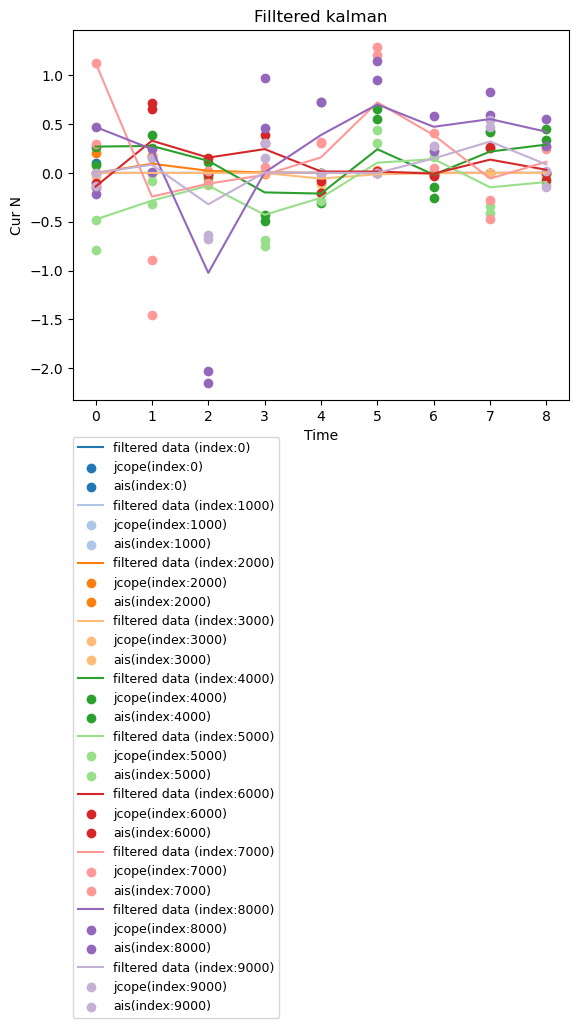

88281

In [53]:
import matplotlib.cm as cm 

print(len(s.x[0]))
#print(f"s.x {s.x}")
#print(f"s.z {s.z}")
data = np.array(s.x).T[0]
plt.title(f"Filltered kalman")
plt.xlabel("Time")
plt.ylabel(f"Cur N")
target_index = np.arange(10)*1000
for n, i in enumerate(target_index):
    dataX = np.array(s.x).T
    dataX = dataX[0][i]
    dataZ = np.array(s.z).T
    dataZ = dataZ[0][i]
    dataY = np.array(s.y).T
    dataY = dataY[0][i]

    plt.plot(np.arange(len(dataX)), dataX, label=f'filtered data (index:{i})', c=cm.tab20(n))
    plt.scatter(np.arange(len(dataX)), dataZ, label=f'jcope(index:{i})', c=cm.tab20(n))
    plt.scatter(np.arange(len(dataX)), dataY, label=f'ais(index:{i})', c=cm.tab20(n))
    
plt.legend(bbox_to_anchor=(0, -0.1), loc='upper left', borderaxespad=0, fontsize=9)
plt.show()
np.sum(np.array(s.x) == np.array(s.x))

## 進捗報告用

C:\Users\nmri\AppData\Local\Temp\ipykernel_10852\4197470621.py:66: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[a, b].scatter(np.arange(len(dataX)), dataZ, label=f'jcope{i}',  c=cm.tab20(n))
C:\Users\nmri\AppData\Local\Temp\ipykernel_10852\4197470621.py:67: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[a, b].scatter(np.arange(len(dataX)), dataY, label=f'ais{i}',  c=(cm.tab20(n)[0], cm.tab20(n)[1], cm.tab20(n)[2], 

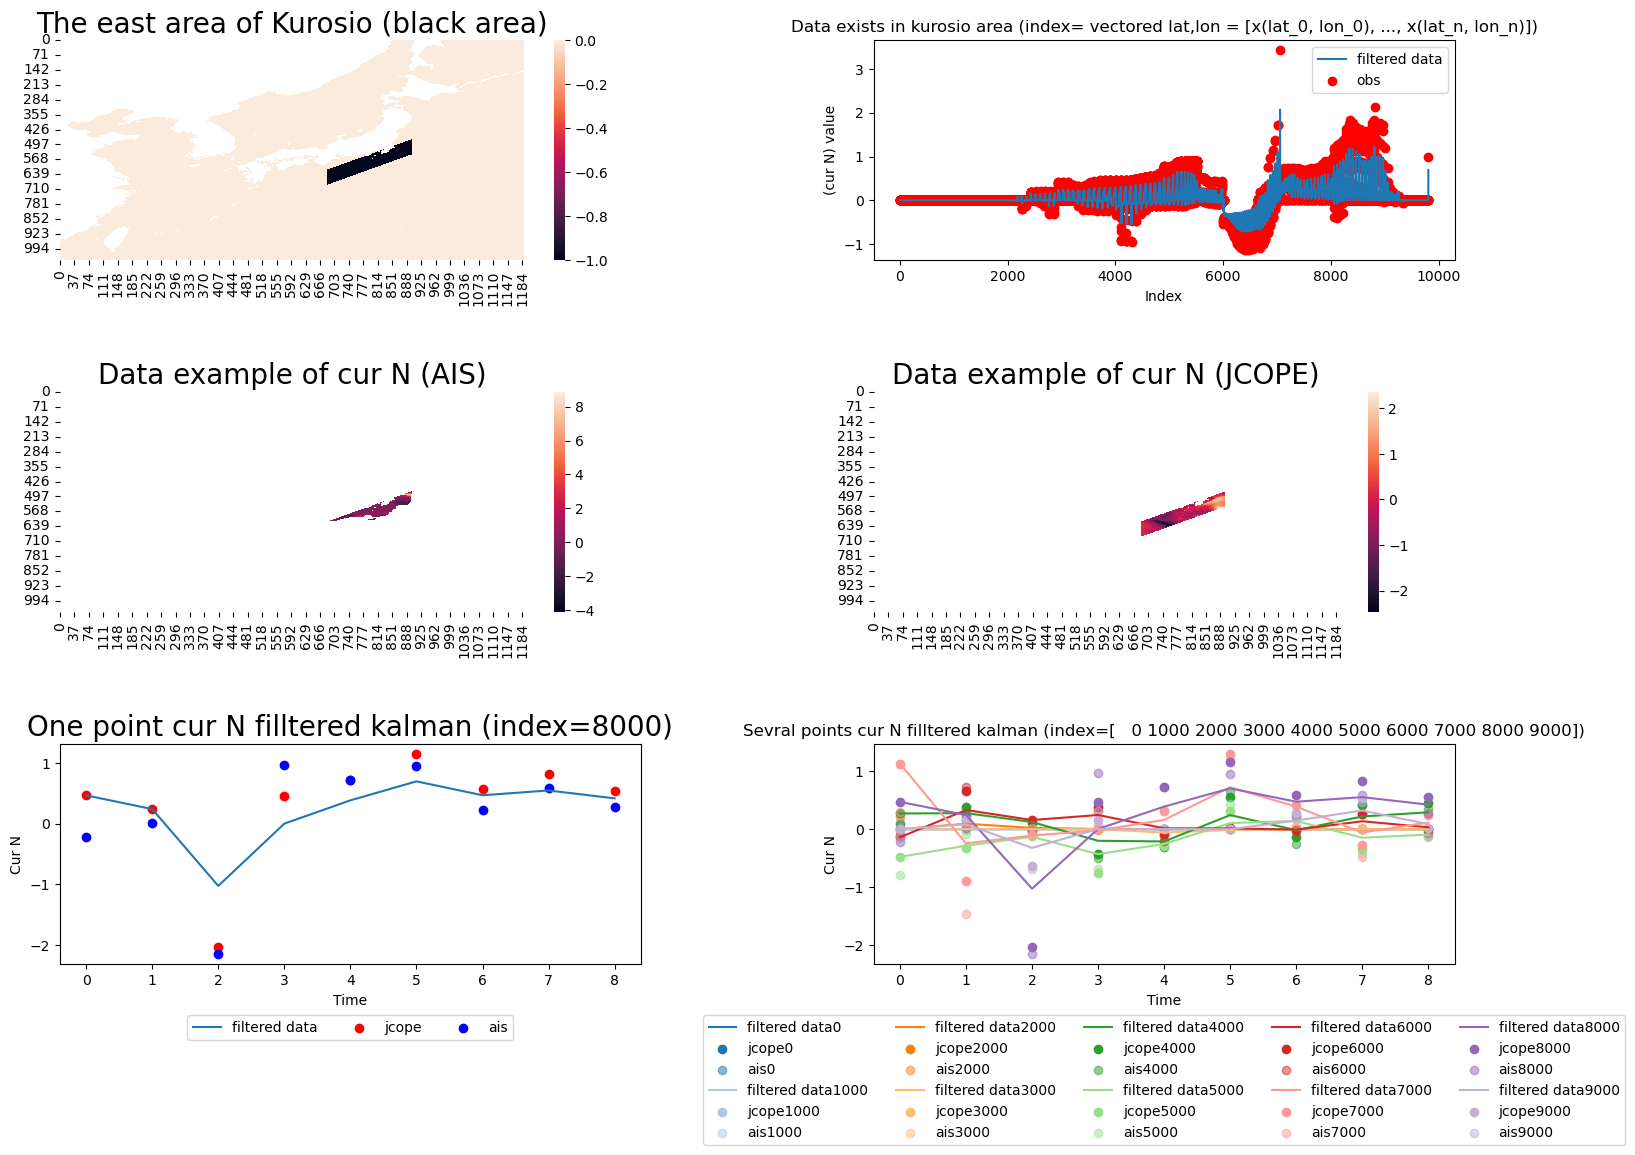

In [96]:
data = kurosio_map_tf*-1*nan_map
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.6, wspace=0.4)
a, b = [0, 0]
axes[a, b].set_title("The east area of Kurosio (black area)", fontsize=20)
sns.heatmap(data, ax=axes[a, b])
    
data = ais_n_mapped[0]*kurosio_map
a, b = [1, 0]
axes[a, b].set_title("Data example of cur N (AIS)", fontsize=20)
axes[a, b].set_xlim(0, 1082)
axes[a, b].set_ylim(0, 1090)
sns.heatmap(data.values, ax=axes[a, b])


a, b = [0, 1]
axes[a, b].set_title("Data exists in kurosio area (index= vectored lat,lon = [x(lat_0, lon_0), ..., x(lat_n, lon_n)])")
axes[a, b].set_xlabel("Index")
axes[a, b].set_ylabel(f"(cur N) value")
axes[a, b].plot(np.arange(len(np.array(s.x)[-1])), np.array(s.x)[-1], label=f'filtered data')
axes[a, b].scatter(np.arange(len(np.array(s.x)[-1])), np.array(s.z)[-1], label=f'obs', c='r')
axes[a, b].legend()


data = jcope_n[0]*kurosio_map
a, b = [1, 1]
axes[a, b].set_title("Data example of cur N (JCOPE)", fontsize=20)
axes[a, b].set_xlim(0, 1082)
axes[a, b].set_ylim(0, 1090)
sns.heatmap(data.values, ax=axes[a, b])

i = 8000
dataX = np.array(s.x).T
dataX = dataX[0][i]
dataZ = np.array(s.z).T
dataZ = dataZ[0][i]
dataY = np.array(s.y).T
dataY = dataY[0][i]
a, b = [2, 0]
axes[a, b].set_title(f"One point cur N filltered kalman (index={i})", fontsize=20)
axes[a, b].set_xlabel("Time")
axes[a, b].set_ylabel(f"Cur N")
axes[a, b].plot(np.arange(len(dataX)), dataX, label=f'filtered data')
axes[a, b].scatter(np.arange(len(dataX)), dataZ, label=f'jcope', c='r')
axes[a, b].scatter(np.arange(len(dataX)), dataY, label=f'ais', c='b')
axes[a, b].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)

data = np.array(s.x).T[0]
plt.title(f"Filltered kalman")
plt.xlabel("Time")
plt.ylabel(f"Cur N")
a, b = [2, 1]
target_index = np.arange(10)*1000
axes[a, b].set_title(f"Sevral points cur N filltered kalman (index={target_index})", fontsize=12)
axes[a, b].set_xlabel("Time")
axes[a, b].set_ylabel(f"Cur N")
for n, i in enumerate(target_index):
    dataX = np.array(s.x).T
    dataX = dataX[0][i]
    dataZ = np.array(s.z).T
    dataZ = dataZ[0][i]
    dataY = np.array(s.y).T
    dataY = dataY[0][i]
    
    axes[a, b].plot(np.arange(len(dataX)), dataX, label=f'filtered data{i}', c=cm.tab20(n))
    axes[a, b].scatter(np.arange(len(dataX)), dataZ, label=f'jcope{i}',  c=cm.tab20(n))
    axes[a, b].scatter(np.arange(len(dataX)), dataY, label=f'ais{i}',  c=(cm.tab20(n)[0], cm.tab20(n)[1], cm.tab20(n)[2], 0.5))
    axes[a, b].legend()
    axes[a, b].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5)

plt.show()